In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sm import NeuralNet, LearnableActivationFunc
from sm import LearnableActivationFunc
from models import CondSM

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 11,    # affects horizontal colorbar ticks
    "ytick.labelsize": 11,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(torch.__version__)

device = 'cuda'    
print(device)

2.10.0+cu126
cuda


In [2]:
X, y = make_moons(n_samples=2_000, shuffle=True, noise=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

train_x = torch.from_numpy(X_train).float()
test_x = torch.from_numpy(X_test).float()
train_y = torch.from_numpy(y_train).float()
test_y = torch.from_numpy(y_test).float()

train_ds = TensorDataset(train_x, train_y)
test_ds = TensorDataset(test_x, test_y)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size)
test_loader = DataLoader(test_ds, batch_size)   

print("data loaded")

data loaded


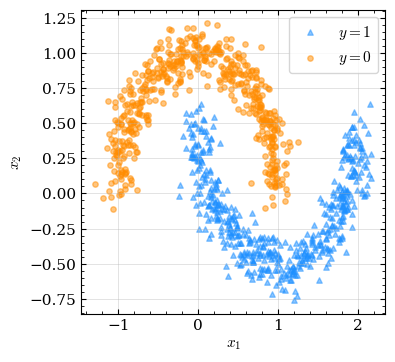

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.set_position([0.18, 0.12, 0.76, 0.83])

ax.scatter(*train_x[train_y == 1][:500].T, s=15, fc='dodgerblue', alpha=.5, ec='dodgerblue', marker='^', label=r'$y = 1$')
ax.scatter(*train_x[train_y == 0][:500].T, s=15, fc='darkorange', alpha=.5, ec='darkorange', label=r'$y = 0$')
ax.set_box_aspect(1)
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(direction='in', which='both')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.grid(which='major', lw=0.5, alpha=0.5)

plt.legend()
plt.savefig('two_moons_data.pdf')
plt.show()

In [57]:
data_type = 'uni_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
class TwoMoons(nn.Module):
    def __init__(self, model, input_dim, hidden_dim, output_dim, device):
        super().__init__()
        
        self.fc_1 = nn.Linear(input_dim, hidden_dim)
        self.fc_2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_5 = nn.Linear(hidden_dim, output_dim)

        self.act_1 = LearnableActivationFunc(model, input_index=0, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)
        self.act_2 = LearnableActivationFunc(model, input_index=0, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)
        self.act_3 = LearnableActivationFunc(model, input_index=0, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)
        self.act_4 = LearnableActivationFunc(model, input_index=0, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)

    def forward(self, x):

        x = self.fc_1(x)
        #x = self.act_1(x)
        #x = self.fc_2(x)
        x = self.act_2(x)
        #x = self.fc_3(x)
        x = self.act_3(x)
        #x = self.fc_4(x)
        x = self.act_4(x)
        x = self.fc_5(x)

        return x

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out

In [12]:
#net = TwoMoons(model, 2, 20, 1, device)
#net = net.to(device)
#x = torch.linspace(-1.5, 1.5, 100).to(device)
#net.eval()
#with torch.no_grad():
#    y = net.act_1(x).detach().cpu()
#plt.plot(x.detach().cpu(), y)
#print(net.act_1.scale_cntrl())
#param_list = [-1.5, 1.5, 1.5, 0.0038004407013444313, 1.5, 1.5]
#y_t = forward_whole_range(model, param_list, 3, -1.5, 1.5, 100)
#plt.plot(x.detach().cpu(), y_t)

In [58]:
net = TwoMoons(model, 2, 5, 1, device)
net = net.to(device)    
#optimizer = torch.optim.SGD(net. parameters(), lr=1e-1, momentum=0.9)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)
loss_fn = nn.BCEWithLogitsLoss()
epochs = 100

act_1_params = []
act_2_params = []
act_3_params = []
act_4_params = []

train_losses = []
train_accuracies = []
test_accuracies = []
test_losses = []

for epoch in range(1, epochs):
    
    running_loss = 0.0
    num_correct = 0
    total_samples = 0
    
    net.train()
    for i, (x, y) in enumerate(train_loader):
        optimizer.zero_grad()
        x = x.to(device)
        y = y.unsqueeze(1).to(device)
        predictions = net(x)
        loss = loss_fn(predictions, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        with torch.no_grad():
            pred = (torch.sigmoid(predictions) >= 0.5).float()
            num_correct += (pred == y).sum().item()
            total_samples += y.size(0)
        
    if epoch % 10 == 0:
        print(f"EPOCH: {epoch}/{epochs} | Loss: {running_loss / len(train_loader.dataset)} | Accuracy: {100.0 * num_correct / total_samples}")    

    train_losses.append(running_loss / len(train_loader.dataset))
    train_accuracies.append(100.0 * num_correct / total_samples)
    
    act_1_params.append(net.act_1.scale_cntrl().detach().cpu().clone())
    act_2_params.append(net.act_2.scale_cntrl().detach().cpu().clone())
    act_3_params.append(net.act_3.scale_cntrl().detach().cpu().clone())
    act_4_params.append(net.act_4.scale_cntrl().detach().cpu().clone())
    
net.eval()
with torch.no_grad():
    running_loss = 0.0
    num_correct = 0
    total_samples = 0
    for (x, y) in test_loader:
        x = x.to(device)
        y = y.unsqueeze(1).to(device)

        predictions = net(x)
        loss = loss_fn(predictions, y)
        running_loss += loss.item()

        pred = (torch.sigmoid(predictions) >= 0.5).float()
        num_correct += (pred == y).sum().item()
        total_samples += y.size(0)
    print(f"Test Loss: {running_loss / len(test_loader.dataset)} | Accuracy: {100.0 * num_correct / total_samples}")

    test_losses.append(running_loss / len(test_loader.dataset))
    test_accuracies.append(100.0 * num_correct / total_samples)
    
torch.save({
        "model_state_dict": net.state_dict(),
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
        "training_loss": train_losses,
        "test_losses": test_losses,
        "act_1_params": act_1_params,
        "act_2_params": act_2_params,
        "act_3_params": act_3_params,
        "act_4_params": act_4_params
    }, f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/data_type={data_type}_two_moons.pth')

EPOCH: 10/100 | Loss: 0.009114819844563802 | Accuracy: 88.73333333333333
EPOCH: 20/100 | Loss: 0.007294281393289566 | Accuracy: 89.86666666666666
EPOCH: 30/100 | Loss: 0.005412032971779506 | Accuracy: 96.46666666666667
EPOCH: 40/100 | Loss: 0.0034903694738944373 | Accuracy: 98.6
EPOCH: 50/100 | Loss: 0.002503206772108873 | Accuracy: 99.0
EPOCH: 60/100 | Loss: 0.0018735119824608167 | Accuracy: 99.4
EPOCH: 70/100 | Loss: 0.001427327665189902 | Accuracy: 99.66666666666667
EPOCH: 80/100 | Loss: 0.0010763471176226933 | Accuracy: 99.66666666666667
EPOCH: 90/100 | Loss: 0.0007801551495989164 | Accuracy: 99.93333333333334
Test Loss: 0.000733534637838602 | Accuracy: 99.8


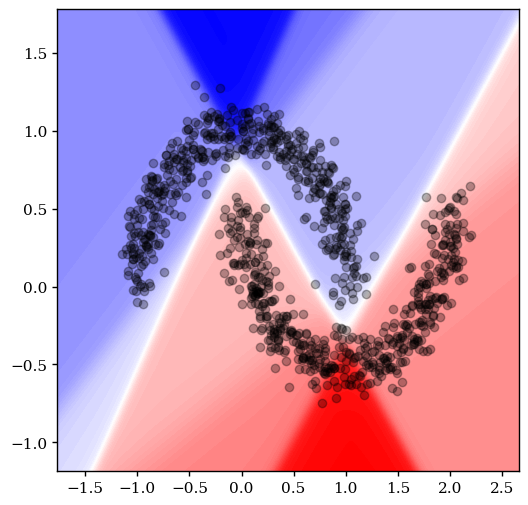

In [59]:
pad = 0.2

dataset = make_moons(1500, noise=0.2)

x_min = dataset[0][:,0].min() - pad
x_max = dataset[0][:,0].max() + pad

y_min = dataset[0][:,1].min() - pad
y_max = dataset[0][:,1].max() + pad
N = 200
X, Y = np.meshgrid(np.linspace(x_min, x_max, N), np.linspace(y_min, y_max, N))
X = X.reshape(-1, 1)
Y = Y.reshape(-1, 1)

input_tensor = torch.cat([torch.from_numpy(X).float(), torch.from_numpy(Y).float()], dim=1)
input_tensor = input_tensor.to(device)

with torch.no_grad():
    out = net(input_tensor).detach().cpu().numpy()
out = out.reshape(N, N)

X = X.reshape(200, 200)
Y = Y.reshape(200, 200)

fig, ax = plt.subplots(figsize=(6,6))
ax.spines[:].set_linewidth(1)
ax.tick_params(width=1)
ax.set_box_aspect(1)
cntrf = ax.contourf(X, Y, out, levels=100, cmap='bwr')

sample_n, _ = make_moons(1_000, noise=0.1)
ax.scatter(*sample_n.T, c='k', alpha=0.3)

#plt.colorbar(cntrf)

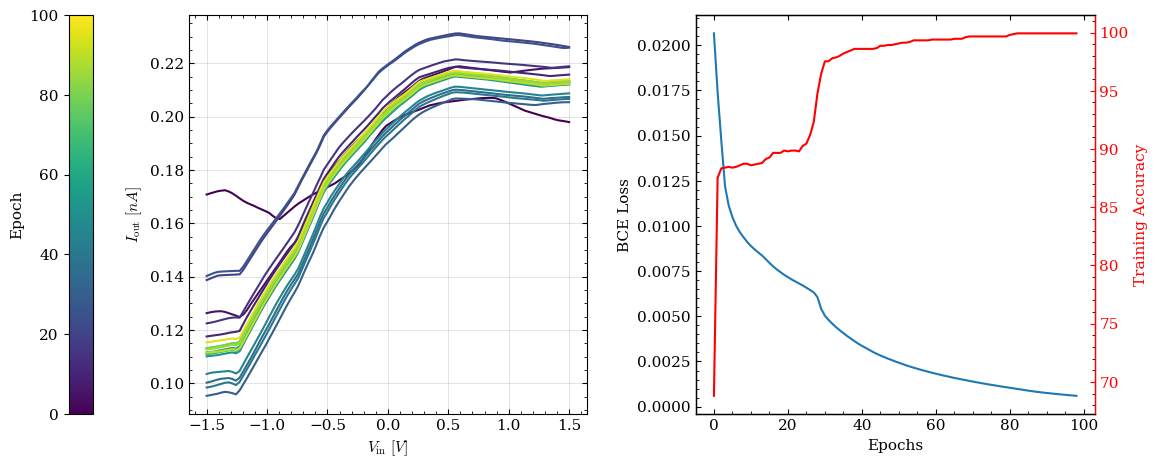

In [61]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm

model.eval()
input_idx = 3
N = 100
x = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
ncols = 2

# --- your original subplots ---
fig, axs = plt.subplots(ncols=ncols, figsize=(6*ncols, 6))
fig.subplots_adjust(wspace=0.2)

for ax in axs:
    ax.set_box_aspect(1)

# --- cmap / norm ---
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=0, vmax=epochs)

# don't overwrite the matplotlib.colors module name; use line_colors
line_colors = cmap(norm(np.linspace(0, epochs-1, epochs)))

# --- left plot ---
for i in range(0, len(act_1_params), 5):
    with torch.no_grad():
        c_volt = act_4_params[i].expand(N, -1)
        c_volt_l = c_volt[:, :input_idx]
        c_volt_r = c_volt[:, input_idx:]
        input_tensor = torch.cat([c_volt_l, x, c_volt_r], dim=1)
        y = model(input_tensor).detach().cpu()
        axs[0].plot(x, y, c=line_colors[i], lw=1.5)

axs[0].minorticks_on()
axs[0].tick_params(top=True, right=True, which='both')
axs[0].tick_params(direction='in', which='both')
axs[0].grid(which='major', lw=0.5, alpha=0.5)
#axs[0].grid(which='minor', lw=0.1, alpha=0.5)
axs[0].set_xlabel(r'$V_{\mathrm{in}} \, \, [V]$')
axs[0].set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')

# --- OPTIONAL reference curve ---
param_list = [-1.5, 1.5, 1.5, 0.0038004407013444313, 1.5, 1.5]
y = forward_whole_range(model, param_list, 3, -1.5, 1.5, N)
# axs[0].plot(x, y)

# --- right plot ---
axs[1].minorticks_on()
axs[1].plot(train_losses)
axs[1].spines[['left', 'top', 'bottom']].set_linewidth(1)
axs[1].tick_params(top=True, right=True)
axs[1].tick_params(which='both', direction='in')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('BCE Loss')

axs1_2 = axs[1].twinx()
axs1_2.set_box_aspect(1)

color = 'r'
axs1_2.minorticks_on()
axs1_2.plot(train_accuracies, c=color, lw=1.5)
axs1_2.tick_params(axis='y', colors=color, labelcolor=color)
axs1_2.set_ylabel('Training Accuracy', c=color)
axs1_2.spines['right'].set_color(color)
axs1_2.spines['right'].set_linewidth(1)
axs1_2.tick_params(which='both', direction='in')

# =========================
# Colorbar: SAME HEIGHT as axs[0]
# (and keep both subplots same size by reserving space on the right too)
# =========================

# (1) create a colorbar axes to the LEFT of axs[0], matching its height exactly
pos0 = axs[0].get_position()      # figure coords bbox for axs[0]
pos1 = axs[1].get_position()      # bbox for axs[1] (for reserving symmetric space)

# =========================
# Colorbar: SAME HEIGHT as axs[0]
# and keep BOTH subplots same size
# =========================

cbar_w = 0.02   # width in figure coordinates
pad   = 0.0    # gap between cbar and axs[0]
reserve = cbar_w + pad

# original positions
pos0 = axs[0].get_position()
pos1 = axs[1].get_position()

# shrink BOTH axes by the same reserved amount
axs[0].set_position([pos0.x0 + reserve, pos0.y0, pos0.width - reserve, pos0.height])
axs[1].set_position([pos1.x0 + reserve, pos1.y0, pos1.width - reserve, pos1.height])

# place colorbar left of the (new) axs[0], same height
pos0_new = axs[0].get_position()
cax = fig.add_axes([pos0_new.x0 - pad - cbar_w - 0.08, pos0_new.y0, cbar_w, pos0_new.height])

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Epoch")
cax.yaxis.set_ticks_position("left")
cax.yaxis.set_label_position("left")
cax.tick_params(direction="out")

plt.show()